<a id='notebook-top'></a>
This notebook estimates the proxy of spurious Doppler velocity presented in SPICE data using linear regression between the intensity gradient and Doppler velocity. This method was also used in [Janvier et al. (2023)](https://ui.adsabs.harvard.edu/abs/2023A%26A...677A.130J/) and [Petrova et al. (2024)](https://ui.adsabs.harvard.edu/abs/2024A%26A...687A..13P/). 
Link to [Figure B.1](#figure-b1).

Note: The internal hyperlink only works on [GitHub Pages](https://yjzhu-solar.github.io/EIS_DKIST_SolO/eis_eui_upflow_ipynb_html/spice_spurious_vel.html) or [nbviewer](https://nbviewer.org/github/yjzhu-solar/EIS_DKIST_SolO/blob/master/ipynb/ms_eis_eui_upflow/spice_spurious_vel.ipynb). Do not click when viewing the notebook on GitHub. 

In [1]:
import numpy as np
from numpy.polynomial import Polynomial
import sunpy
import sunpy.map
import astropy
import astropy.units as u
import astropy.constants as const
from astropy.visualization import (ImageNormalize, AsinhStretch,
                                  PercentileInterval, LinearStretch)
from astropy.visualization.wcsaxes import SphericalCircle
from matplotlib.patches import Circle
from mpl_toolkits.axes_grid1.anchored_artists import (AuxTransformBox,
                                                      AnchoredOffsetbox,
                                                      TextArea,
                                                      VPacker)

from fancy_colorbar import plot_colorbar
from scipy.stats import linregress
import matplotlib.patheffects as path_effects
from matplotlib.patches import Ellipse

import matplotlib.pyplot as plt
from glob import glob
import os
import cmcrameri.cm as cmcm
import corner

In [2]:
ms_style_dict = {'text.usetex': True, 'font.family': 'serif', 'axes.linewidth': 1.2,
                 'xtick.major.width': 1.2, 'xtick.major.size': 4,
                 'ytick.major.width': 1.2, 'ytick.major.size': 4,
                 'xtick.minor.width': 1.2, 'xtick.minor.size': 2,
                 'ytick.minor.width': 1.2, 'ytick.minor.size': 2,
                 'xtick.direction': 'in', 'ytick.direction': 'in',
                 'text.latex.preamble': r'\usepackage[T1]{fontenc}'
                 r'\usepackage{amsmath}' r'\usepackage{siunitx}'
                 r'\sisetup{detect-all=True}'}

In [3]:
saffron_dir = '../../src/SPICE/slimane/solo_L2.5_spice-n-ras_20221024T231535_V07_150995398-000/con-06/'

In [4]:
saffron_NeVIII_con06_file = glob(os.path.join(saffron_dir, '*770.42-ne_8*.fits'))[0]

In [5]:
saffron_NeVIII_con06_maps = sunpy.map.Map(saffron_NeVIII_con06_file)
saffron_NeVIII_con06_intensity_map = saffron_NeVIII_con06_maps[0]
saffron_NeVIII_con06_intensity_map = saffron_NeVIII_con06_intensity_map.submap([0,120]*u.pix,
                                                                                top_right=[192,699]*u.pix)

saffron_spice_NeVIII_vel_map_data = saffron_NeVIII_con06_maps[1].data
saffron_spice_NeVIII_vel_map_data = (saffron_spice_NeVIII_vel_map_data/np.nanmedian(saffron_spice_NeVIII_vel_map_data) - 1)*const.c.to_value(u.km/u.s)
saffron_spice_NeVIII_vel_map_data = saffron_spice_NeVIII_vel_map_data - np.nanmedian(saffron_spice_NeVIII_vel_map_data[120:699,:], axis=0)
saffron_spice_NeVIII_vel_map_data[401+120:411+120,:] = np.nan # mask some bad fitting probably caused by 
saffron_NeVIII_con06_velocity_map = sunpy.map.Map(saffron_spice_NeVIII_vel_map_data, saffron_NeVIII_con06_maps[1].meta)
saffron_NeVIII_con06_velocity_map.meta['bunit'] = 'km/s'

saffron_NeVIII_con06_velocity_map = saffron_NeVIII_con06_velocity_map.submap([0,120]*u.pix, top_right=[192,699]*u.pix)
saffron_NeVIII_con06_velocity_map.plot_settings['aspect'] = saffron_NeVIII_con06_velocity_map.scale.axis2/saffron_NeVIII_con06_velocity_map.scale.axis1
saffron_NeVIII_con06_velocity_map.plot_settings['norm'] = ImageNormalize(vmin=-40,vmax=40)
saffron_NeVIII_con06_velocity_map.plot_settings['cmap'] = 'coolwarm'
saffron_NeVIII_con06_velocity_map.plot_settings['interpolation'] = "none"

In [6]:
def add_psf_scale_circle(ax, text, size, font_color='black', edgecolor='white', facecolor='none',
                          fontsize=12, spherical_circle=True, loc='upper right', **kwargs):
    
    circle_box = AuxTransformBox(ax.get_transform('world'))

    if spherical_circle:
        circle = SphericalCircle((0, 0), size, transform=ax.get_transform('world'),
                                 edgecolor=edgecolor, facecolor=facecolor, **kwargs)
    else:
        circle = Circle((0, 0), size, transform=ax.get_transform('world'),
                        edgecolor=edgecolor, facecolor=facecolor, **kwargs)

    circle_box.add_artist(circle)

    text_box = TextArea(text, textprops=dict(color=font_color, fontsize=fontsize))

    packer = VPacker(children=[text_box, circle_box],align='center', pad=0, sep=5)
    
    ax.add_artist(AnchoredOffsetbox(child=packer, loc=loc, frameon=False,
                                    pad=0.1,borderpad=0.5))


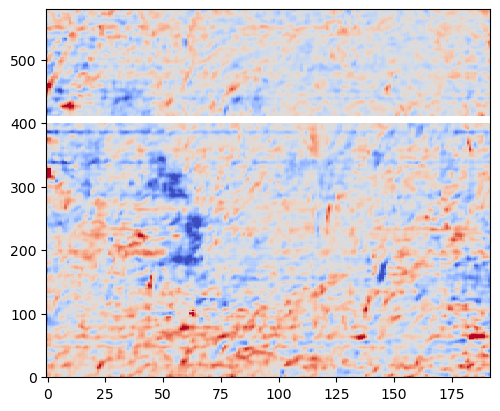

In [7]:
fig, ax = plt.subplots(figsize=(6,4), layout="constrained")
ax.imshow(saffron_NeVIII_con06_velocity_map.data, **saffron_NeVIII_con06_velocity_map.plot_settings)

In [8]:
saffron_NeVIII_con06_intensity_grad_x = np.gradient(saffron_NeVIII_con06_intensity_map.data, axis=1)
saffron_NeVIII_con06_intensity_grad_y = np.gradient(saffron_NeVIII_con06_intensity_map.data, axis=0)
saffron_NeVIII_con06_intensity_grad_x_std = np.nanstd(saffron_NeVIII_con06_intensity_grad_x.flatten())
saffron_NeVIII_con06_intensity_grad_y_std = np.nanstd(saffron_NeVIII_con06_intensity_grad_y.flatten())
saffron_NeVIII_con06_intensity_grad_x_greatest_mask = \
    np.where((np.abs(saffron_NeVIII_con06_intensity_grad_x) > saffron_NeVIII_con06_intensity_grad_x_std)\
             & (np.isfinite(saffron_NeVIII_con06_intensity_grad_x)) \
             & (np.isfinite(saffron_NeVIII_con06_velocity_map.data)))
saffron_NeVIII_con06_intensity_grad_y_greatest_mask = \
   np.where((np.abs(saffron_NeVIII_con06_intensity_grad_y) > saffron_NeVIII_con06_intensity_grad_y_std)\
            & (np.isfinite(saffron_NeVIII_con06_intensity_grad_y)) \
            & (np.isfinite(saffron_NeVIII_con06_velocity_map.data)))

In [9]:
saffron_NeVIII_con06_intensity_grad_x_masked = saffron_NeVIII_con06_intensity_grad_x[saffron_NeVIII_con06_intensity_grad_x_greatest_mask]
saffron_NeVIII_con06_intensity_grad_y_masked = saffron_NeVIII_con06_intensity_grad_y[saffron_NeVIII_con06_intensity_grad_y_greatest_mask]
saffron_NeVIII_con06_velocity_map_masked_x = saffron_NeVIII_con06_velocity_map.data[saffron_NeVIII_con06_intensity_grad_x_greatest_mask]
saffron_NeVIII_con06_velocity_map_masked_y = saffron_NeVIII_con06_velocity_map.data[saffron_NeVIII_con06_intensity_grad_y_greatest_mask]

lingress_x = linregress(saffron_NeVIII_con06_intensity_grad_x_masked.flatten(),
                        saffron_NeVIII_con06_velocity_map_masked_x.flatten())
lingress_y = linregress(saffron_NeVIII_con06_intensity_grad_y_masked.flatten(),
                        saffron_NeVIII_con06_velocity_map_masked_y.flatten())

# pfit_x = Polynomial.fit(saffron_NeVIII_con06_intensity_grad_x_masked.flatten(),
#                         saffron_NeVIII_con06_velocity_map_masked_x.flatten(), 1)
# pfit_y = Polynomial.fit(saffron_NeVIII_con06_intensity_grad_y_masked.flatten(),
#                         saffron_NeVIII_con06_velocity_map_masked_y.flatten(), 1)

In [10]:
predict_spurious_velocity = lingress_x.slope*saffron_NeVIII_con06_intensity_grad_x + \
                            lingress_y.slope*saffron_NeVIII_con06_intensity_grad_y

In [11]:
print(lingress_x)
print(lingress_y)

LinregressResult(slope=21.008637464472265, intercept=-1.2067282516566293, rvalue=0.466198355904446, pvalue=0.0, stderr=0.3603927010525746, intercept_stderr=0.08567441253709032)
LinregressResult(slope=-54.64245518318692, intercept=-0.8796011531531489, rvalue=-0.35438665072204417, pvalue=0.0, stderr=1.263295347521184, intercept_stderr=0.08523494260433638)


<a id='figure-b1'></a>
### Figure B.1
(You may have to pull down to see the notebook preview of the figure)

[back to top](#notebook-top) 

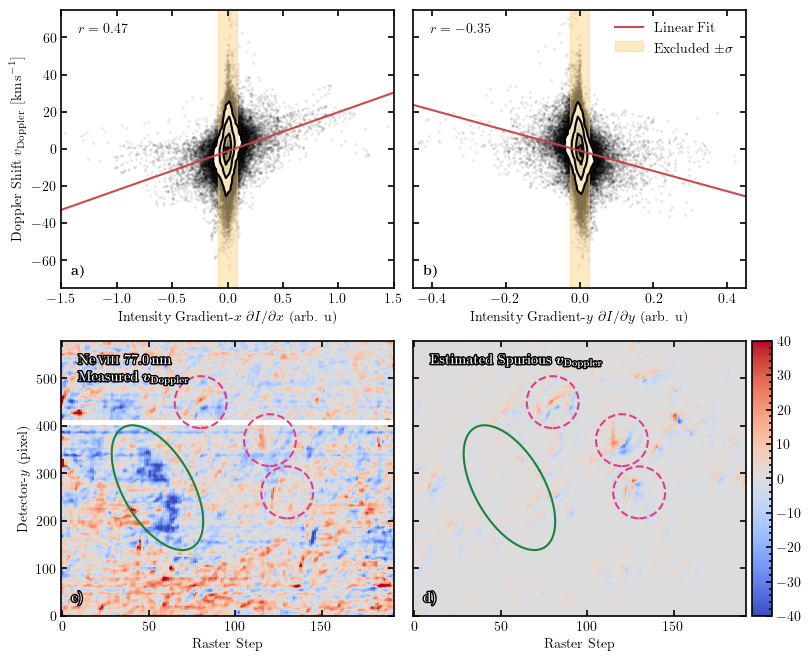

In [12]:
bottom_panels_height = 8/2*580/192*saffron_NeVIII_con06_velocity_map.plot_settings['aspect']

with plt.rc_context(ms_style_dict):
   fig, ((ax1,ax2), (ax3,ax4)) = plt.subplots(2,2, figsize=(8,6.5), layout="constrained",
                                             gridspec_kw={'height_ratios': [6.5 - bottom_panels_height, bottom_panels_height]})

   corner.hist2d(saffron_NeVIII_con06_intensity_grad_x,
            saffron_NeVIII_con06_velocity_map.data,
               bins=100, ax=ax1, range=((-1.5,1.5),(-75,75))) 
   ax1.plot(np.linspace(-2,2,3), lingress_x.slope*(np.linspace(-2,2,3)) + lingress_x.intercept,
            color='#CB4042', lw=1.5, alpha=0.95)
   ax1.axvspan(-saffron_NeVIII_con06_intensity_grad_x_std, saffron_NeVIII_con06_intensity_grad_x_std, color='#FAD689', alpha=0.5)
   ax1.text(0.05, 0.95, r"$r = {{{:.2f}}}$".format(lingress_x.rvalue),
            transform=ax1.transAxes, fontsize=10, va="top", ha="left")
   
   ax1.set_xlabel(r"Intensity Gradient-$x$ $\partial I/\partial x$ (arb. u)")
   ax1.set_ylabel(r"Doppler Shift $v_{\mathrm{Doppler}}$ $[\mathrm{km\,s}^{-1}]$")
   
   corner.hist2d(saffron_NeVIII_con06_intensity_grad_y,
            saffron_NeVIII_con06_velocity_map.data,
               bins=100, ax=ax2, range=((-0.45,0.45),(-75,75)))
   
   ln2, = ax2.plot(np.linspace(-2,2,3), lingress_y.slope*(np.linspace(-2,2,3)) + lingress_y.intercept,
            color='#CB4042', lw=1.5, alpha=0.95, label="Linear Fit")
   region2 = ax2.axvspan(-saffron_NeVIII_con06_intensity_grad_y_std, saffron_NeVIII_con06_intensity_grad_y_std, color='#FAD689', alpha=0.5,
                         label=r"Excluded $\pm\sigma$")
   ax2.text(0.05, 0.95, r"$r = {{{:.2f}}}$".format(lingress_y.rvalue),
            transform=ax2.transAxes, fontsize=10, va="top", ha="left")
   
   ax2.set_xlabel(r"Intensity Gradient-$y$ $\partial I/\partial y$ (arb. u)")
   # ax.set_xlabel(r'$\rm{d} I/\rm{d}x$')
   # ax.set_ylabel(r'$V_{\rm Doppler}$ $[\rm km\,s^{-1}]$')
   ax2.legend(handles=[ln2, region2], loc='upper right', fontsize=10, frameon=False)



   im3 = ax3.imshow(saffron_NeVIII_con06_velocity_map.data, **saffron_NeVIII_con06_velocity_map.plot_settings)

   im4 = ax4.imshow(predict_spurious_velocity, **saffron_NeVIII_con06_velocity_map.plot_settings)
   clb, clb_ax = plot_colorbar(im4, ax4, bbox_to_anchor=(1.02,0,0.06,1), orientation='vertical')
   ax3.set_xlabel("Raster Step")
   ax3.set_ylabel(r"Detector-$y$ (pixel)")
   ax4.set_xlabel("Raster Step")
   ax1.tick_params(which="both", right=True, top=True,)
   ax2.tick_params(which="both", right=True, top=True,labelleft=False)
   ax3.tick_params(which="both", right=True, top=True)
   ax4.tick_params(which="both", right=True, top=True,labelleft=False)

   ax1.text(0.03, 0.04, r"\textbf{a)}", transform=ax1.transAxes, fontsize=10, va="bottom", ha="left")
   ax2.text(0.03, 0.04, r"\textbf{b)}", transform=ax2.transAxes, fontsize=10, va="bottom", ha="left")
   ax3.text(0.03, 0.04, r"\textbf{c)}", transform=ax3.transAxes, fontsize=10, va="bottom", ha="left",
            color="w", path_effects=[path_effects.Stroke(linewidth=2, foreground='black'), path_effects.Normal()])
   ax4.text(0.03, 0.04, r"\textbf{d)}", transform=ax4.transAxes, fontsize=10, va="bottom", ha="left",
            color="w", path_effects=[path_effects.Stroke(linewidth=2, foreground='black'), path_effects.Normal()])
   
   ax3.text(0.05, 0.95, r"\textbf{Ne\,\textsc{viii} 77.0\,nm}" + \
            "\n" + r"\textbf{Measured} $\boldsymbol{v_{\rm Doppler}}$",
            transform=ax3.transAxes, fontsize=10, va="top", ha="left", linespacing=1.5,
            color="w", path_effects=[path_effects.Stroke(linewidth=2, foreground='black'), path_effects.Normal()])
   
   ax4.text(0.05, 0.95, r"\textbf{Estimated Spurious} $\boldsymbol{v_{\rm Doppler}}$",
            transform=ax4.transAxes, fontsize=10, va="top", ha="left", linespacing=1.5,
            color="w", path_effects=[path_effects.Stroke(linewidth=2, foreground='black'), path_effects.Normal()])

   ellipse_t = np.linspace(0, 2*np.pi, 360)
   ellipse_x0 = 55
   ellipse_y0 = 270
   ellipse_a = 20
   ellipse_b = 40
   ellipse_theta = np.deg2rad(30)

   ellipse_x = ellipse_x0 + ellipse_a*np.cos(ellipse_t)*np.cos(ellipse_theta) - ellipse_b*np.sin(ellipse_t)*np.sin(ellipse_theta)
   ellipse_y = ellipse_y0 + (ellipse_a*np.cos(ellipse_t)*np.sin(ellipse_theta) + ellipse_b*np.sin(ellipse_t)*np.cos(ellipse_theta))/saffron_NeVIII_con06_velocity_map.plot_settings['aspect']
   ax3.plot(ellipse_x, ellipse_y, color='#1B813E', lw=1.5,)
   ax4.plot(ellipse_x, ellipse_y, color='#1B813E', lw=1.5,)

   r1_params = {'xy':(80, 450), 'width': 30, 'height': 30/saffron_NeVIII_con06_velocity_map.plot_settings['aspect'],
                       'ec':"#E03C8A", 'fill': False, 'lw':1.5, 'ls':"--"}
   
   r2_params = {'xy':(120, 370), 'width': 30, 'height': 30/saffron_NeVIII_con06_velocity_map.plot_settings['aspect'],
                       'ec':"#E03C8A", 'fill': False, 'lw':1.5, 'ls':"--"}
   
   r3_params = {'xy':(130, 260), 'width': 30, 'height': 30/saffron_NeVIII_con06_velocity_map.plot_settings['aspect'],
                       'ec':"#E03C8A", 'fill': False, 'lw':1.5, 'ls':"--"}

   for ax_ in (ax3, ax4):
      ax_.add_patch(Ellipse(**r1_params))
      ax_.add_patch(Ellipse(**r2_params))
      ax_.add_patch(Ellipse(**r3_params))
   
   fig.savefig("../../figs/ms_eis_eui_upflow/spice_spurious_velocity.pdf", bbox_inches='tight', dpi=300)
   plt.show()

   